In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import numpy as np
import tifffile
from skimage import measure
import sys
sys.path.append('../../src')
import traceUtilities as tu
import visualisationTools as vt
from scipy.signal import find_peaks, peak_widths

In [4]:
alldata = pd.read_excel('/home/marcotti-lab/git-repos/In-Vivo-Analysis-efferent/alpha9.xlsx')
alldata = alldata[alldata['discard']!=1]
drive = '/media/marcotti-lab'

alldata['Folder'] = alldata['Folder'].str.replace('Z:',drive).str.replace('\\','/')


In [5]:
result_rows = [] # Every row is a unique pair of cells.
results_cells_rows = [] # Every row is a unique cell.
alltraces = {}
for j,el in alldata.iterrows():
    if j<1e10:
        folder = Path(el['Folder'])
        trace_filename  = folder / 'processedMovies' / 'traces.csv'
        try:
            trace = pd.read_csv(trace_filename,index_col=0)
            frames = trace['Frame']
            trace.drop(columns=['Frame'],inplace=True)
            
            trace.iloc[:,:] = tu.rollingMedianCorrection(trace,rollingN=2000)
            
            traces_df = trace.copy()
            traces_df['Time (s)'] = frames/el['fps']
            alltraces[el['Folder']] = traces_df
            #Estimating activity using z score normalization, which is more robust to baseline drift than dF/F. 
            traces_z = (trace - trace.mean())/trace.std()
            # Find calcium peaks in the traces using find_peaks from scipy

            peaks = []
            for i in traces_z.columns:
                trace_z = traces_z[i]       
                peaks, _ = find_peaks(trace_z, prominence=3.5, width = 0.5*el['fps'],distance = 0.5*el['fps'])
                peak_row = pd.DataFrame({
                    'Folder': el['Folder'],
                    'Age': el['Age'],
                    'Strain': el['Strain'],
                    'Mouse ID': el['Mouse ID'],
                    'Trace': i,
                    'Frequency': len(peaks)/(frames.shape[0]/el['fps'])*60
                },index=[0])
                results_cells_rows.append(peak_row)

            #Traces have groups of neighboring frames that are constant due to skipped frames. We remove those frames to avoid biasing the correlation.
            trace = trace[trace.diff().abs().sum(axis=1)>0]


            # We add a dataframe with the cross correlation between every pair of traces
            corr = trace.corr()
            corr = corr.where(~np.tril(np.ones(corr.shape)).astype(bool)).stack().reset_index()
            corr.columns = ['Trace1','Trace2','Correlation']
            corr['Folder'] = el['Folder']
            corr['Age'] = el['Age']
            corr['Strain'] = el['Strain']
            corr['Mouse ID'] = el['Mouse ID']
            corr['Duration'] = trace.shape[0]/el['fps']


            #For each pair of cells, determine the distance from the mask
            masks = tifffile.imread(folder / 'processedMovies' / 'Masks.tif')
            props = measure.regionprops(measure.label(masks))
            centroids_by_label = {prop.label: np.array(prop.centroid) for prop in props}
            for i,row in corr.iterrows():
                trace1 = int(row['Trace1'].split('_')[-1])
                trace2 = int(row['Trace2'].split('_')[-1])
                if trace1 not in centroids_by_label or trace2 not in centroids_by_label:
                    corr.at[i,'Distance'] = np.nan
                    continue
                distance = np.linalg.norm(centroids_by_label[trace1]-centroids_by_label[trace2])*el['um/pixel']
                corr.at[i,'Distance'] = distance

            result_rows.append(corr) 



        except FileNotFoundError:
            print(f"File not found: {trace_filename}")
            continue

results_df = pd.concat(result_rows, ignore_index=True)
results_cells_df = pd.concat(results_cells_rows, ignore_index=True)


File not found: /media/marcotti-lab/Users/Francesca/Data/2025/2025_09_04_a9KO-Myo15-GCaMP6f_P10_in vivo/4_002/processedMovies/traces.csv
File not found: /media/marcotti-lab/Users/Francesca/Data/2025/2025_09_08_Myo15-GCaMP6f_P8_in vivo/10_002/processedMovies/traces.csv


In [6]:
alltraces

{'/media/marcotti-lab/Users/Francesca/Data/2025/2025_08_05_a9KO-Myo15-GCaMP6f_P7_in vivo/1':           ROI_1      ROI_2      ROI_3      ROI_4      ROI_5      ROI_6  \
 0      0.000000   0.000000   0.000000   0.000000   0.000000   0.000000   
 1      0.000000   0.000000   0.000000   0.000000   0.000000   0.000000   
 2      0.000000   0.000000   0.000000   0.000000   0.000000   0.000000   
 3      0.000000   0.000000   0.000000   0.000000   0.000000   0.000000   
 4      0.000000   0.000000   0.000000   0.000000   0.000000   0.000000   
 ...         ...        ...        ...        ...        ...        ...   
 1495 -90.658048  24.554569 -26.840517  28.277581 -17.690345 -71.458505   
 1496 -90.953711  21.605149 -29.816502  25.415488 -13.691586 -66.402629   
 1497 -89.132819  20.008702 -32.852627  24.592999  -8.584414 -61.550260   
 1498 -88.110509  19.691443 -32.558292  24.591584  -4.766345 -58.300740   
 1499 -88.045872  19.204496 -32.400246  25.100071  -2.813103 -56.987127   
 
      

In [8]:
results_df['Distance_bin'] 

0                    NaN
1            (0.0, 10.0]
2           (60.0, 70.0]
3         (100.0, 110.0]
4         (110.0, 120.0]
               ...      
136033      (10.0, 20.0]
136034       (0.0, 10.0]
136035      (30.0, 40.0]
136036      (20.0, 30.0]
136037               NaN
Name: Distance_bin, Length: 136038, dtype: category
Categories (70, interval[float64, right]): [(0.0, 10.0] < (10.0, 20.0] < (20.0, 30.0] < (30.0, 40.0] ... (660.0, 670.0] < (670.0, 680.0] < (680.0, 690.0] < (690.0, 700.0]]

In [7]:
#Bin the distance column, keep the center of the bin as the value, and add a column with the bin edges

results_df['Distance_bin'] = pd.cut(results_df['Distance'], bins=np.arange(0, results_df['Distance'].max() + 10, 10))
results_df['Distance_bin_center'] = results_df['Distance_bin'].apply(lambda x: x.mid)

AttributeError: 'float' object has no attribute 'mid'

In [72]:
results_df_avg = results_df.groupby(['Folder','Distance_bin_center']).agg({'Correlation':'mean','Duration':'first','Strain':'first','Age':'first'}).dropna().reset_index()

/tmp/ipykernel_10024/3720383570.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results_df_avg = results_df.groupby(['Folder','Distance_bin_center']).agg({'Correlation':'mean','Duration':'first','Strain':'first','Age':'first'}).dropna().reset_index()


(0.0, 1.0)

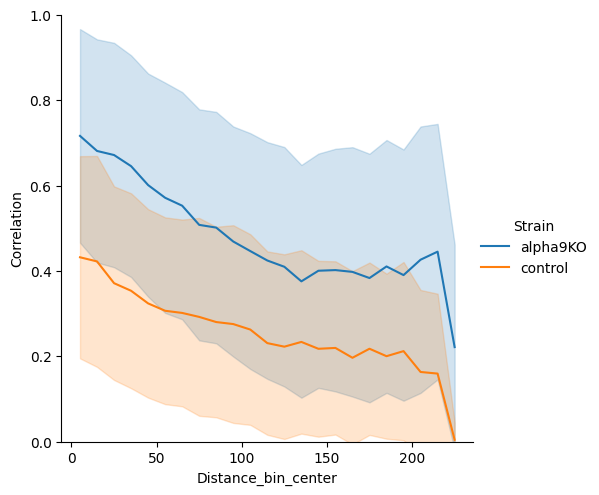

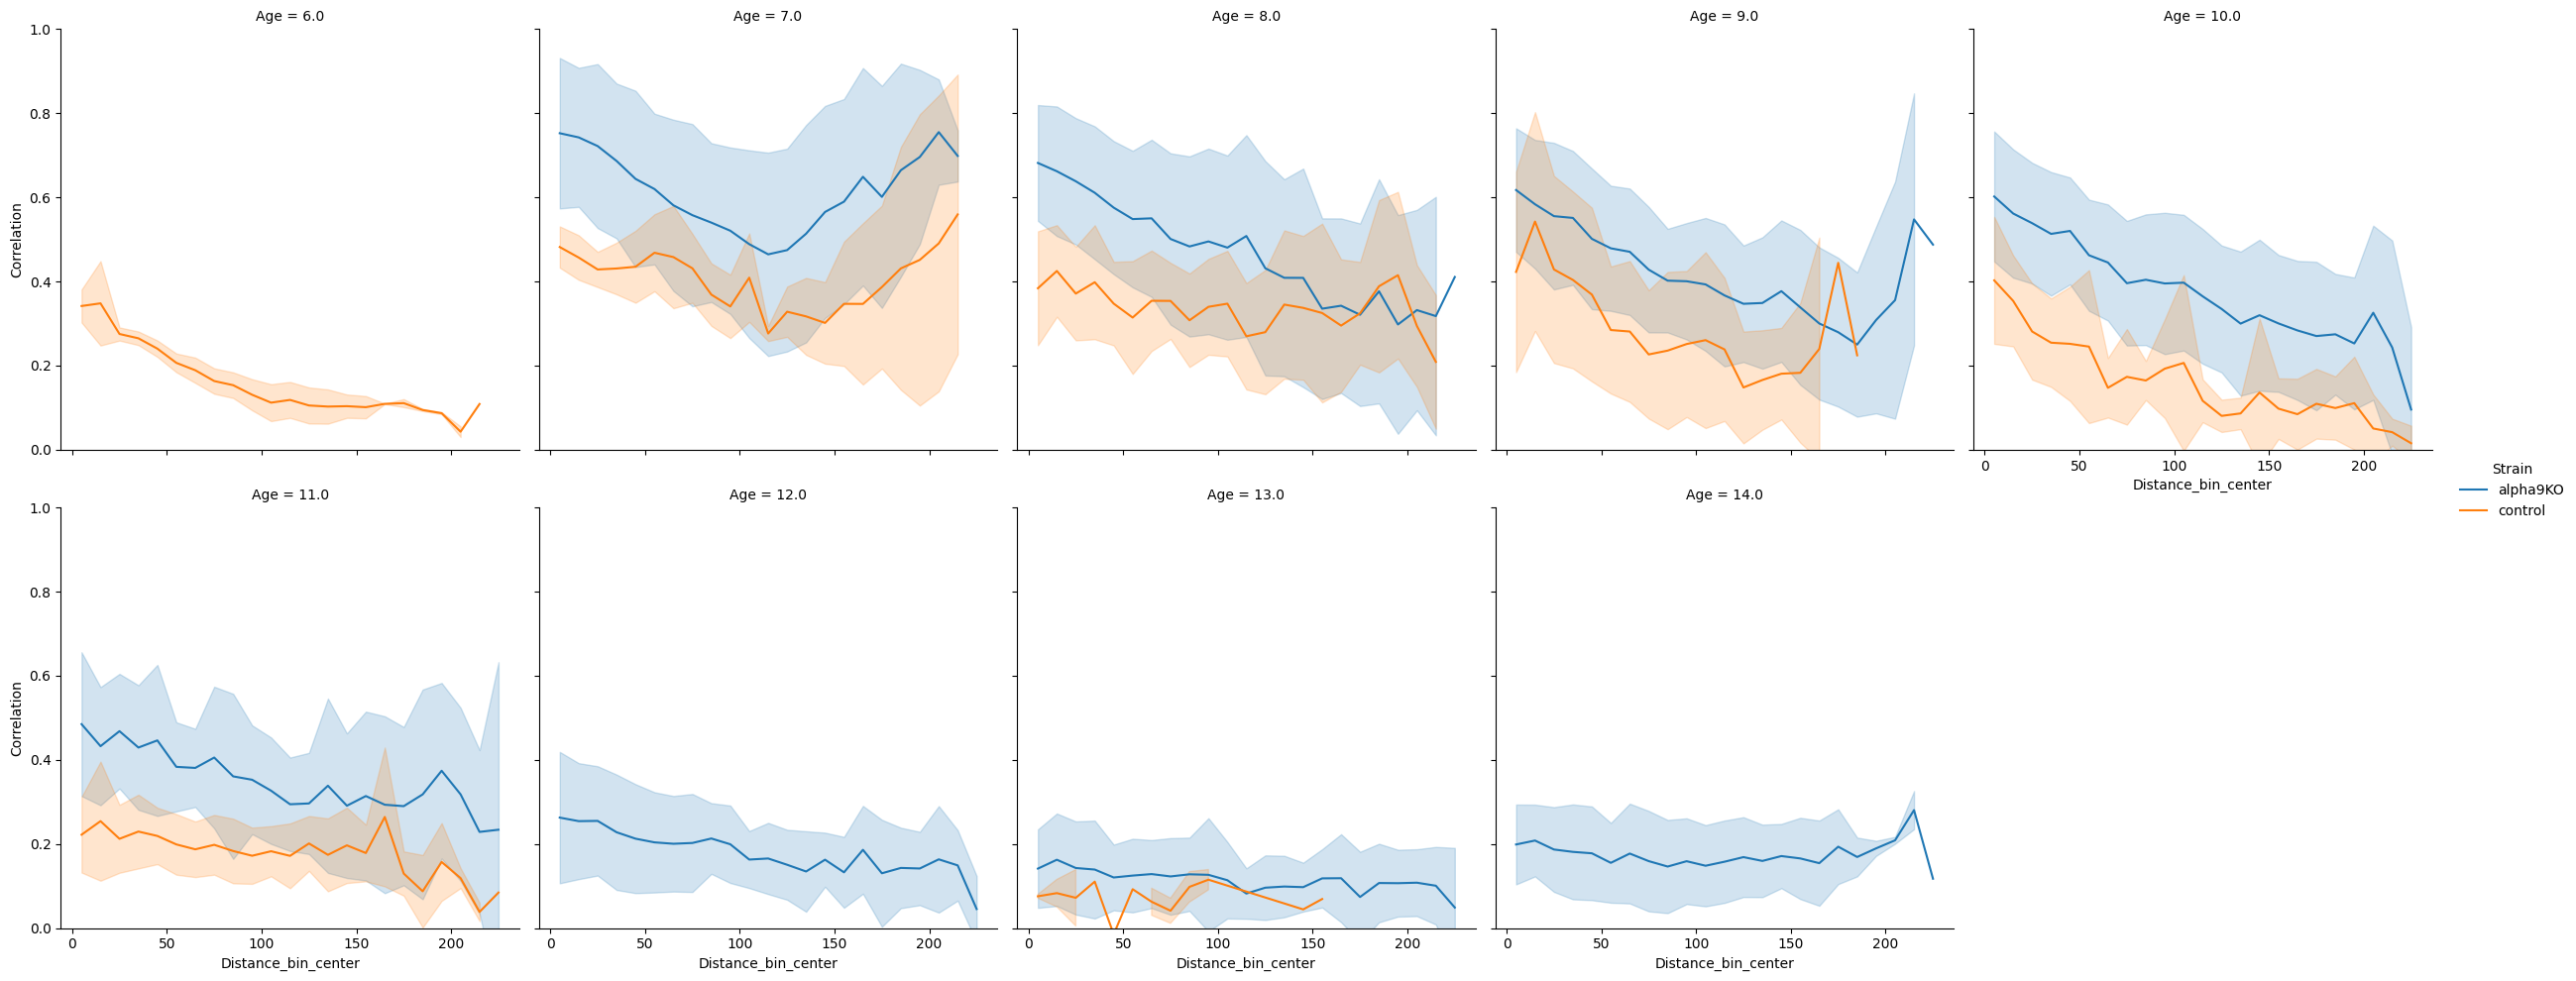

In [75]:
import seaborn as sns

def corrcoeff_mean(x):
    # We use fisher's transformation to average the correlation coefficients, which is more accurate than averaging the correlation coefficients directly.
    x = np.clip(np.asarray(x), -0.999999, 0.999999)
    return np.tanh(np.arctanh(x).mean())


sns.relplot(
    data=results_df[(results_df['Duration']>300) & (results_df['Age']<=10)],
    x='Distance_bin_center',
    hue='Strain',
    y='Correlation',
    kind='line',
    estimator=corrcoeff_mean,
    errorbar='sd'
 )
plt.ylim(0,1)


sns.relplot(
    data=results_df_avg[results_df_avg['Duration']>300],
    x='Distance_bin_center',
    hue='Strain',
    y='Correlation',
    kind='line',
    estimator=corrcoeff_mean,
    errorbar='sd',
    col='Age',
    col_wrap=5
 )
plt.ylim(0,1)

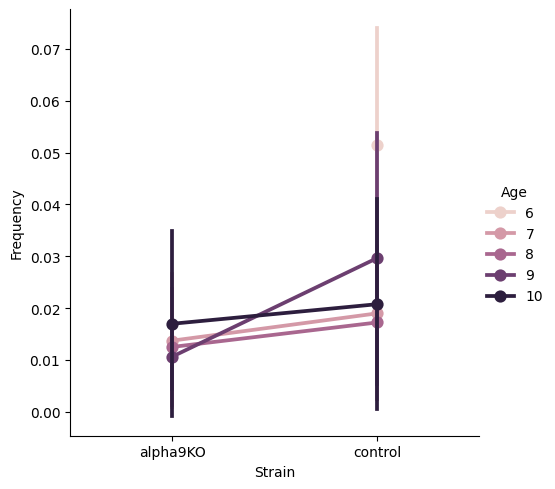

In [79]:
sns.catplot(
    data=results_cells_df[results_cells_df['Age']<=10],
    y='Frequency',
    x='Strain',
    hue='Age',
    kind='point',
    estimator='mean',
    errorbar='sd'
 )